In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy
import pickle
import random
import seaborn as sns
import matplotlib.ticker as ticker


from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [194]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                mean_abs_cntrl = np.mean( [max_cntrl_[v], np.abs(min_cntrl_[v])] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_abs_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

params_bistability_boundary_LC_exc = []
params_bistability_boundary_LC_inh = []

params_bistability_boundary_LC_up_exc = []
params_bistability_boundary_LC_up_inh = []

1
[2.0]
[1.6]


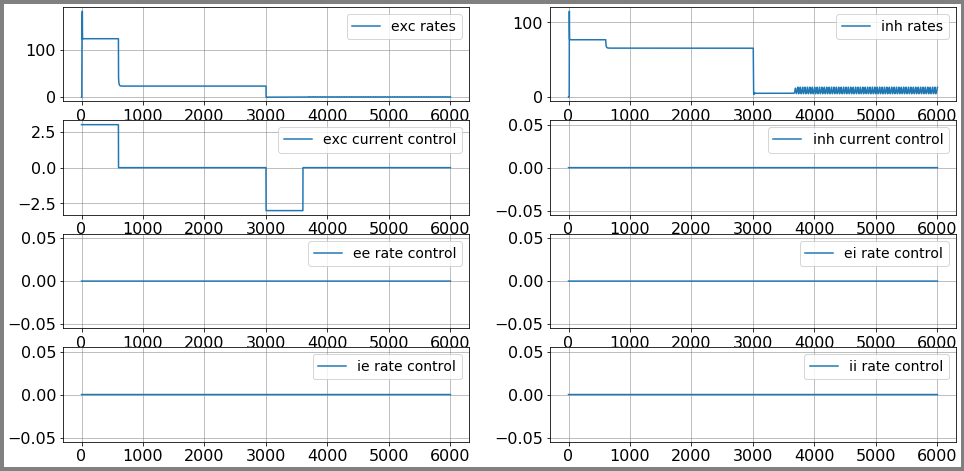

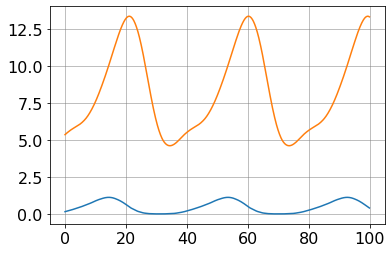

In [187]:
print(len(params_bistability_boundary_LC_up_exc))
print(params_bistability_boundary_LC_up_exc)
print(params_bistability_boundary_LC_up_inh)

aln.params['duration'] = 6000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 3.)

aln.params.ext_exc_current = 0.4 * 5.
aln.params.ext_inh_current = 0.33 * 5.
# bistable -0.16

# 3.65 7.4

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

"""
plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
"""
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0, path_=path, filename_="bistability")

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

plt.plot(np.arange(0,100, 0.1), aln.rates_exc[0,-1000:])      
plt.plot(np.arange(0,100, 0.1), aln.rates_inh[0,-1000:])


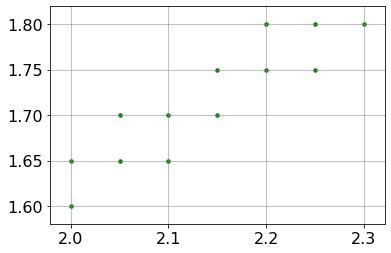

In [207]:
aln.params.ext_exc_current = 0.41 * 5.
aln.params.ext_inh_current = 0.33 * 5.

params_bistability_boundary_LC_up_exc.append(aln.params.ext_exc_current)
params_bistability_boundary_LC_up_inh.append(aln.params.ext_inh_current)

plt.scatter(params_bistability_boundary_LC_exc, params_bistability_boundary_LC_inh, s=6, c="grey")
plt.scatter(params_bistability_boundary_LC_up_exc, params_bistability_boundary_LC_up_inh, s=12, c="green")

In [208]:
#params_bistability_exc.pop()
#params_bistability_inh.pop()

with open('bistability_boundary_LC_up.pickle','wb') as f:
    pickle.dump([params_bistability_boundary_LC_up_exc, params_bistability_boundary_LC_up_inh], f)
    
with open('bistability_boundary_LC_up.pickle','rb') as f:
    load_array = pickle.load(f)
    
print(load_array)

[[2.0, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3000000000000003, 2.25, 2.2, 2.15, 2.1, 2.05], [1.6, 1.6500000000000001, 1.7000000000000002, 1.7000000000000002, 1.75, 1.7999999999999998, 1.7999999999999998, 1.7999999999999998, 1.75, 1.75, 1.7000000000000002, 1.6500000000000001, 1.6500000000000001]]
